Adding project root to python path

In [42]:
import sys
from pathlib import Path

PROJECT_ROOT = Path().resolve().parent

sys.path.append(str(PROJECT_ROOT))

Imports

In [43]:
import pandas as pd
import matplotlib.pyplot as plt

from src.data_loader import (
    download_prices,
    compute_returns
)

from src.signals import (
    compute_momentum_signal
)

from src.backtest import (
    compute_strategy_returns,
    aggregate_portfolio_returns,
    compute_cumulative_returns
)

from src.performance import (
    annualized_return,
    annualized_volatility,
    sharpe_ratio,
    max_drawdown
)

Defining tickers for quick editing, adding SPY for benchmarking later

In [44]:
TICKERS = [
    "AAPL",
    "MSFT",
    "AMZN",
    "NVDA",
    "GLD"
]

Downloading data and a quick preview

In [45]:
prices = download_prices(TICKERS)

prices.head()

Ticker,AAPL,AMZN,GLD,MSFT,NVDA
Date,,,,,
2010-01-04,6.406482,6.6950,109.800003,23.077383,0.423784
2010-01-05,6.417557,6.7345,109.699997,23.084837,0.429972
2010-01-06,6.315477,6.6125,111.510002,22.943167,0.432722
2010-01-07,6.303802,6.5000,110.820000,22.704563,0.424242
2010-01-08,6.345712,6.6760,111.370003,22.861149,0.425159


Computing the returns on the assets

In [46]:
returns = compute_returns(prices)

returns.head()

Ticker,AAPL,AMZN,GLD,MSFT,NVDA
Date,,,,,
2010-01-05,0.001729,0.005900,-0.000911,0.000323,0.014603
2010-01-06,-0.015906,-0.018116,0.016500,-0.006137,0.006396
2010-01-07,-0.001849,-0.017013,-0.006188,-0.010400,-0.019597
2010-01-08,0.006648,0.027077,0.004963,0.006897,0.002161
2010-01-11,-0.008821,-0.024041,0.013289,-0.012720,-0.014016


Computing the momentum signals

In [47]:
signals = compute_momentum_signal(
    prices,
    lookback=252
)

signals.tail()

Ticker,AAPL,AMZN,GLD,MSFT,NVDA
Date,,,,,
2019-12-24,1.0,1.0,1.0,1.0,1.0
2019-12-26,1.0,1.0,1.0,1.0,1.0
2019-12-27,1.0,1.0,1.0,1.0,1.0
2019-12-30,1.0,1.0,1.0,1.0,1.0
2019-12-31,1.0,1.0,1.0,1.0,1.0


Computing the strategy returns for each asset

In [48]:
strategy_returns = compute_strategy_returns(
    returns,
    signals
)

strategy_returns.head()

Ticker,AAPL,AMZN,GLD,MSFT,NVDA
Date,,,,,
2011-01-04,0.005219,0.004288,-0.023551,-0.003932,0.003160
2011-01-05,0.008180,0.013026,-0.002820,0.003204,-0.076728
2011-01-06,-0.000808,-0.008324,-0.004019,-0.029286,-0.138398
2011-01-07,0.007162,-0.001991,-0.001868,0.007633,0.027936
2011-01-10,0.018832,-0.004367,0.004042,0.013287,0.038248


Aggregating the return across the portfolio

In [49]:
portfolio_returns = aggregate_portfolio_returns(
    strategy_returns
)

portfolio_returns.head()

Date
2011-01-04   -0.002963
2011-01-05   -0.011027
2011-01-06   -0.036167
2011-01-07    0.007774
2011-01-10    0.014009
dtype: float64

Computing the cumulative returns

In [50]:
cumulative_returns = compute_cumulative_returns(
    portfolio_returns
)

cumulative_returns.tail()

Date
2019-12-24    2.785093
2019-12-26    2.831187
2019-12-27    2.826628
2019-12-30    2.808516
2019-12-31    2.821570
dtype: float64

Plotting the Time-Series Momentum strategy cumulative returns

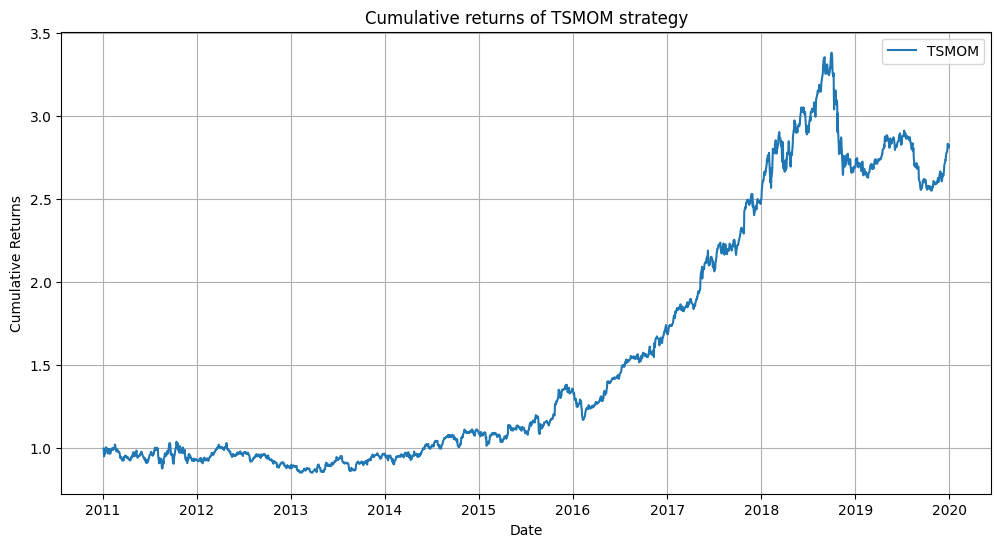

In [ ]:
plt.figure(figsize=(12, 6))

plt.plot(
    cumulative_returns,
    label="TSMOM"
)

plt.title(
    "Cumulative returns of TSMOM strategy"
)

plt.xlabel("Date")
plt.ylabel("Cumulative Returns")

plt.legend()

plt.grid(True)

plt.show()

Adding SPY as benchmark for the strategy and aligning its starting period with the portfolio

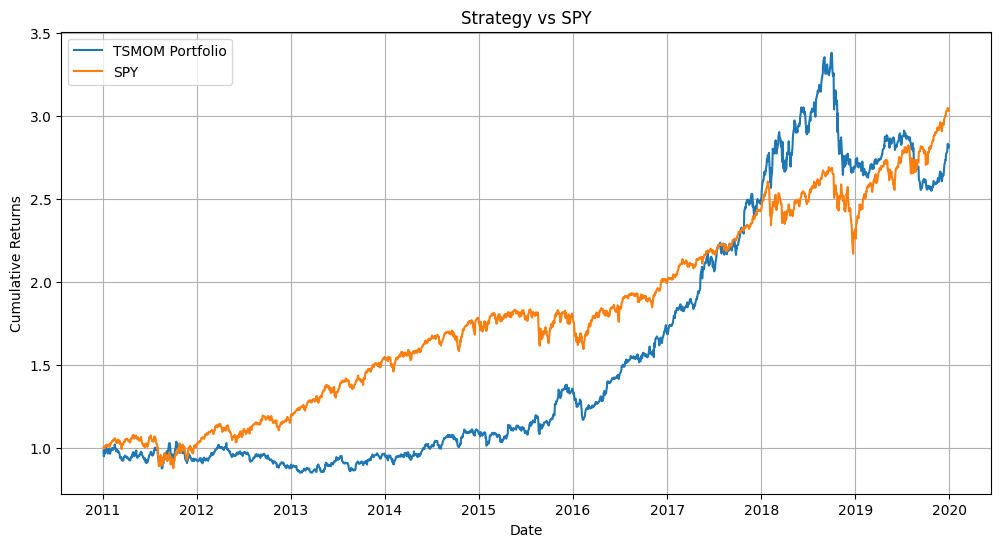

In [52]:
spy_prices = download_prices(["SPY"])

spy_returns = compute_returns(spy_prices)

benchmark_returns = spy_returns["SPY"]

benchmark_start = benchmark_returns.index.min() + pd.DateOffset(years=1)

benchmark_returns = benchmark_returns.loc[
    benchmark_returns.index >= benchmark_start
]

benchmark_cumulative = (
    1 + benchmark_returns
).cumprod()

aligned_strategy = cumulative_returns.loc[
    cumulative_returns.index >= benchmark_start
]

plt.figure(figsize=(12, 6))

plt.plot(
    aligned_strategy,
    label="TSMOM Portfolio"
)

plt.plot(
    benchmark_cumulative,
    label="SPY"
)

plt.title(
    "Strategy vs SPY"
)

plt.xlabel("Date")
plt.ylabel("Cumulative Returns")

plt.legend()

plt.grid(True)

plt.show()

Calculating performance metrics

In [53]:
ann_return = annualized_return(
    portfolio_returns
)

ann_vol = annualized_volatility(
    portfolio_returns
)

sr = sharpe_ratio(
    portfolio_returns
)

mdd = max_drawdown(
    cumulative_returns
)

print("PERFORMANCE:")
print(f"Annualized Return: {ann_return:.2%}")
print(f"Annualized Volatility: {ann_vol:.2%}")
print(f"Sharpe Ratio: {sr:.2f}")
print(f"Maximum Drawdown: {mdd:.2%}")

PERFORMANCE:
Annualized Return: 12.74%
Annualized Volatility: 15.43%
Sharpe Ratio: 0.83
Maximum Drawdown: -24.54%
